# What this notebook does

**Recap** 

Building up from the full pipeline we built in `prediction/full_pipeline_v3.ipynb`, we realized that our LSTM, although learning some signals, still seems pretty week despite training with multiple hyperparameters. On average the loss we get is only ~0.6, and the best accuracy was ~67%, which is more random guessing.

Random Forest continually performed the best.

In the following notebooks we will attempt to improve our pipeline by applying feature engineering, improving random forest, and also redesigning the LSTM.

# 01 Feature Engineering Experiments

## Objective
This notebook prepares the modeling dataset for Brent commodity direction prediction.

It performs the following steps:
- loads daily aggregated sentiment/event features
- loads Brent daily price data
- merges both sources by date
- creates price-derived features and the next-day direction target
- engineers lagged, rolling, and interaction features
- evaluates feature-set quality using a quick Random Forest experiment
- saves the improved merged dataset for later notebooks

## 1. Imports and configuration

In [39]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
# =========================
# Paths
# =========================

try:
    BASE = Path.cwd().parent   # if notebook is inside prediction/
except:
    BASE = Path.cwd()

OUT_DIR = BASE / "finetuning" / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Set these to your actual files
SENTIMENT_PATH = OUT_DIR / "sentiment_cache.csv"   # change this
PRICE_PATH = BASE / "data" / "raw" / "daily_last_2y" / "csv" / "brent_daily_20260228_075143.csv"   # change this if needed

# Output files
MERGED_OUTPUT_PATH = OUT_DIR / "merged_modeling_brent.csv"
META_OUTPUT_PATH = OUT_DIR / "feature_engineering_metadata_brent.json"

TARGET_COL = "target_up"
DATE_COL = "date"
RANDOM_STATE = 42

## 2. Load the dataset and standardize column names

In [41]:
sent_df = pd.read_csv(SENTIMENT_PATH)
price_df = pd.read_csv(PRICE_PATH)

print("Sentiment shape:", sent_df.shape)
print("Price shape:", price_df.shape)

Sentiment shape: (5118, 2)
Price shape: (517, 2)


In [42]:
sent_df = sent_df.rename(columns={"trading_day": "date"})
price_df = price_df.rename(columns={"value": "price"})

sent_df["date"] = pd.to_datetime(sent_df["date"])
price_df["date"] = pd.to_datetime(price_df["date"])

price_df["price"] = pd.to_numeric(price_df["price"], errors="coerce")

sent_df = sent_df.sort_values("date").reset_index(drop=True)
price_df = price_df.sort_values("date").reset_index(drop=True)

In [43]:
print("Sentiment columns:")
print(sent_df.columns.tolist())

print("\nPrice columns:")
print(price_df.columns.tolist())

Sentiment columns:
['date', 'sentiment_score']

Price columns:
['date', 'price']


## 3. Aggregate sentiment by date

In [44]:
sent_daily = sent_df.groupby("date").agg({
    "sentiment_score": ["mean", "std", "count"]
}).reset_index()

sent_daily.columns = ["date", "avg_sentiment", "sentiment_std", "news_volume"]

sent_daily.head()

,date,avg_sentiment,sentiment_std,news_volume
0,2024-04-01,0.883525,NaN,1
1,2024-04-02,0.391358,0.403185,8
2,2024-04-03,0.063482,0.669059,8
3,2024-04-04,0.230306,0.545027,10
4,2024-04-05,-0.276484,0.675993,10


## 4. Merge sentiment features with Brent price data
This creates the daily modeling table used for downstream experiments.

In [45]:
merged_df = pd.merge(price_df, sent_daily, on="date", how="inner")
merged_df = merged_df.sort_values("date").reset_index(drop=True)

In [46]:
merged_df.head()

,date,price,avg_sentiment,sentiment_std,news_volume
0,2024-04-01,NaN,0.883525,NaN,1
1,2024-04-02,87.63,0.391358,0.403185,8
2,2024-04-03,90.60,0.063482,0.669059,8
3,2024-04-04,90.32,0.230306,0.545027,10
4,2024-04-05,92.81,-0.276484,0.675993,10


In [47]:
# Clean immediately after merge
df = merged_df.copy()

df = df[df["price"].notna()].copy()
df["sentiment_std"] = df["sentiment_std"].fillna(0)

display(df.head())
print(df.shape)

,date,price,avg_sentiment,sentiment_std,news_volume
1,2024-04-02,87.63,0.391358,0.403185,8
2,2024-04-03,90.60,0.063482,0.669059,8
3,2024-04-04,90.32,0.230306,0.545027,10
4,2024-04-05,92.81,-0.276484,0.675993,10
5,2024-04-08,91.73,0.008295,0.642375,20


(479, 5)


## 5. Create price features
These features capture recent momentum, trend, and volatility from Brent prices.

In [48]:
df["log_return"] = np.log(df["price"] / df["price"].shift(1))
df["roll5_ret"] = df["log_return"].rolling(5).sum()
df["roll10_ret"] = df["log_return"].rolling(10).sum()
df["roll20_vol"] = df["log_return"].rolling(20).std()

df["ma5"] = df["price"].rolling(5).mean()
df["ma20"] = df["price"].rolling(20).mean()
df["ma5_ratio"] = df["price"] / df["ma5"]
df["ma20_ratio"] = df["price"] / df["ma20"]

df.head()

,date,price,avg_sentiment,sentiment_std,news_volume,log_return,roll5_ret,roll10_ret,roll20_vol,ma5,ma20,ma5_ratio,ma20_ratio
1,2024-04-02,87.63,0.391358,0.403185,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-04-03,90.60,0.063482,0.669059,8,0.033331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-04-04,90.32,0.230306,0.545027,10,-0.003095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-04-05,92.81,-0.276484,0.675993,10,0.027195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-04-08,91.73,0.008295,0.642375,20,-0.011705,NaN,NaN,NaN,90.618,NaN,1.012271,NaN


## 6. Target definition
The target is whether the next day's return is positive.

In [49]:
df[TARGET_COL] = (df["log_return"].shift(-1) > 0).astype(int)

print(df[[DATE_COL, "price", "log_return", TARGET_COL]].head(10))

         date  price  log_return  target_up
1  2024-04-02  87.63         NaN          1
2  2024-04-03  90.60    0.033331          0
3  2024-04-04  90.32   -0.003095          1
4  2024-04-05  92.81    0.027195          0
5  2024-04-08  91.73   -0.011705          1
6  2024-04-09  92.13    0.004351          0
7  2024-04-10  91.57   -0.006097          0
8  2024-04-11  91.49   -0.000874          1
9  2024-04-12  93.12    0.017659          0
10 2024-04-15  90.84   -0.024789          1


## 7. Engineer extra sentiment features

In [51]:
# -------------------------
# Lagged sentiment features
# -------------------------
lag_source_cols = [
    "avg_sentiment",
    "sentiment_std",
    "topic_w_sentiment",
    "sentiment_volw",
    "composite_price_signal",
    "supply_price_signal",
    "demand_price_signal",
    "inventory_price_signal",
    "transport_price_signal",
    "policy_price_signal",
    "weather_price_signal",
    "macro_price_signal",
    "outage_price_signal",
]

existing_lag_cols = [c for c in lag_source_cols if c in df.columns]

for col in existing_lag_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag2"] = df[col].shift(2)
    df[f"{col}_lag3"] = df[col].shift(3)

In [52]:
# -------------------------
# Rolling sentiment features
# -------------------------
if "avg_sentiment" in df.columns:
    df["avg_sentiment_roll3_mean"] = df["avg_sentiment"].rolling(3).mean()
    df["avg_sentiment_roll5_mean"] = df["avg_sentiment"].rolling(5).mean()
    df["avg_sentiment_roll3_std"]  = df["avg_sentiment"].rolling(3).std()
    df["avg_sentiment_roll5_std"]  = df["avg_sentiment"].rolling(5).std()

if "sentiment_std" in df.columns:
    df["sentiment_std_roll3_mean"] = df["sentiment_std"].rolling(3).mean()
    df["sentiment_std_roll5_mean"] = df["sentiment_std"].rolling(5).mean()

In [53]:
# -------------------------
# Price lags
# -------------------------
price_lag_cols = ["log_return", "roll5_ret", "roll10_ret", "roll20_vol", "ma5_ratio", "ma20_ratio"]

for col in price_lag_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag2"] = df[col].shift(2)

In [54]:
# -------------------------
# Interaction features
# -------------------------
if {"avg_sentiment", "log_return"}.issubset(df.columns):
    df["avg_sentiment_x_log_return"] = df["avg_sentiment"] * df["log_return"]

if {"sentiment_std", "roll5_ret"}.issubset(df.columns):
    df["sentiment_std_x_roll5_ret"] = df["sentiment_std"] * df["roll5_ret"]

if {"avg_sentiment", "roll20_vol"}.issubset(df.columns):
    df["avg_sentiment_x_roll20_vol"] = df["avg_sentiment"] * df["roll20_vol"]

if {"composite_price_signal", "log_return"}.issubset(df.columns):
    df["composite_signal_x_log_return"] = df["composite_price_signal"] * df["log_return"]

## 8. Drop missing rows after lags

In [55]:
before_rows = len(df)
df = df.dropna().reset_index(drop=True)
after_rows = len(df)

print("Rows before dropna:", before_rows)
print("Rows after dropna :", after_rows)
print("Rows removed      :", before_rows - after_rows)

Rows before dropna: 479
Rows after dropna : 457
Rows removed      : 22


## 9. Inspect current dataframe
`target_up` measures whether the price went UP the next day. It uses ONLY PRICE. Not based on sentiment.
| Today (features) | Tomorrow price movement | target_up |
| ---------------- | ----------------------- | --------- |
| data at day t    | price goes UP           | 1         |
| data at day t    | price goes DOWN         | 0         |


In [56]:
print(df.shape)
df.head()

(457, 41)


,date,price,avg_sentiment,sentiment_std,news_volume,log_return,roll5_ret,roll10_ret,roll20_vol,ma5,...,roll10_ret_lag2,roll20_vol_lag1,roll20_vol_lag2,ma5_ratio_lag1,ma5_ratio_lag2,ma20_ratio_lag1,ma20_ratio_lag2,avg_sentiment_x_log_return,sentiment_std_x_roll5_ret,avg_sentiment_x_roll20_vol
0,2024-05-02,84.81,-0.128828,0.790458,10,0.014968,-0.038059,-0.040780,0.018552,86.996,...,-0.034094,0.018057,0.015663,0.953180,0.994163,0.931428,0.979751,-0.001928,-0.030084,-0.002390
1,2024-05-03,83.60,-0.308522,0.675821,8,-0.014370,-0.073210,-0.050839,0.017257,85.726,...,-0.069240,0.018552,0.018057,0.974872,0.953180,0.948387,0.931428,0.004433,-0.049477,-0.005324
2,2024-05-07,82.69,0.110975,0.553279,15,-0.010945,-0.067226,-0.054252,0.017243,84.576,...,-0.040780,0.017257,0.018552,0.975200,0.974872,0.939695,0.948387,-0.001215,-0.037195,0.001914
3,2024-05-08,82.44,-0.030889,0.598770,12,-0.003028,-0.067876,-0.068556,0.017107,83.418,...,-0.050839,0.017243,0.017257,0.977701,0.975200,0.934213,0.939695,0.000094,-0.040642,-0.000528
4,2024-05-09,83.27,-0.164963,0.632030,14,0.010018,-0.003357,-0.066773,0.017456,83.362,...,-0.054252,0.017107,0.017243,0.988276,0.977701,0.936515,0.934213,-0.001653,-0.002122,-0.002880


In [60]:
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True))

target_up
0    231
1    226
Name: count, dtype: int64
target_up
0    0.50547
1    0.49453
Name: proportion, dtype: float64


## Feature sets

In [61]:
base_features = [
    "avg_sentiment",
    "sentiment_std",
    "news_volume",
    "topic_w_sentiment",
    "log_news_vol",
    "sentiment_volw",
    "composite_price_signal",
    "supply_price_signal",
    "demand_price_signal",
    "inventory_price_signal",
    "transport_price_signal",
    "policy_price_signal",
    "weather_price_signal",
    "macro_price_signal",
    "outage_price_signal",
    "log_return",
    "roll5_ret",
    "roll10_ret",
    "roll20_vol",
    "ma5_ratio",
    "ma20_ratio",
]

base_features = [c for c in base_features if c in df.columns]

engineered_sentiment_features = [
    c for c in df.columns
    if (
        "avg_sentiment_lag" in c or
        "sentiment_std_lag" in c or
        "avg_sentiment_roll" in c or
        "sentiment_std_roll" in c
    )
]

engineered_price_lag_features = [
    c for c in df.columns
    if (
        "log_return_lag" in c or
        "roll5_ret_lag" in c or
        "roll10_ret_lag" in c or
        "roll20_vol_lag" in c or
        "ma5_ratio_lag" in c or
        "ma20_ratio_lag" in c
    )
]

engineered_event_lag_features = [
    c for c in df.columns if "_price_signal_lag" in c
]

interaction_features = [c for c in df.columns if "_x_" in c]

feature_sets = {
    "base_only": base_features,
    "base_plus_sentiment_lags": list(dict.fromkeys(base_features + engineered_sentiment_features)),
    "base_plus_price_lags": list(dict.fromkeys(base_features + engineered_price_lag_features)),
    "base_plus_event_lags": list(dict.fromkeys(base_features + engineered_event_lag_features)),
    "base_plus_interactions": list(dict.fromkeys(base_features + interaction_features)),
    "all_engineered": list(dict.fromkeys(
        base_features
        + engineered_sentiment_features
        + engineered_price_lag_features
        + engineered_event_lag_features
        + interaction_features
    ))
}

for k, v in feature_sets.items():
    print(k, "->", len(v), "features")

base_only -> 9 features
base_plus_sentiment_lags -> 21 features
base_plus_price_lags -> 21 features
base_plus_event_lags -> 9 features
base_plus_interactions -> 12 features
all_engineered -> 36 features


## 11. Chronological split

In [62]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

Train rows: 365
Test rows : 92


### Quick evaluator

In [63]:
def evaluate_feature_set(train_df, test_df, feature_cols, target_col):
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    return {
        "model_obj": model,
        "accuracy": accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "preds": preds,
        "probs": probs,
        "feature_cols": feature_cols
    }

## 12. Run experiments

In [64]:
results = []

for name, feats in feature_sets.items():
    if len(feats) == 0:
        continue

    r = evaluate_feature_set(train_df, test_df, feats, TARGET_COL)
    results.append({
        "feature_set": name,
        "n_features": len(feats),
        "accuracy": r["accuracy"],
        "f1": r["f1"],
        "roc_auc": r["roc_auc"],
        "model_obj": r["model_obj"],
        "feature_cols": r["feature_cols"]
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df[["feature_set", "n_features", "accuracy", "f1", "roc_auc"]]

,feature_set,n_features,accuracy,f1,roc_auc
0,base_plus_sentiment_lags,21,0.500000,0.500000,0.554343
1,all_engineered,36,0.543478,0.511628,0.520645
2,base_plus_interactions,12,0.489130,0.525253,0.450403
3,base_only,9,0.478261,0.520000,0.442335
4,base_plus_event_lags,9,0.478261,0.520000,0.442335
5,base_plus_price_lags,21,0.434783,0.365854,0.392027


### Visualization

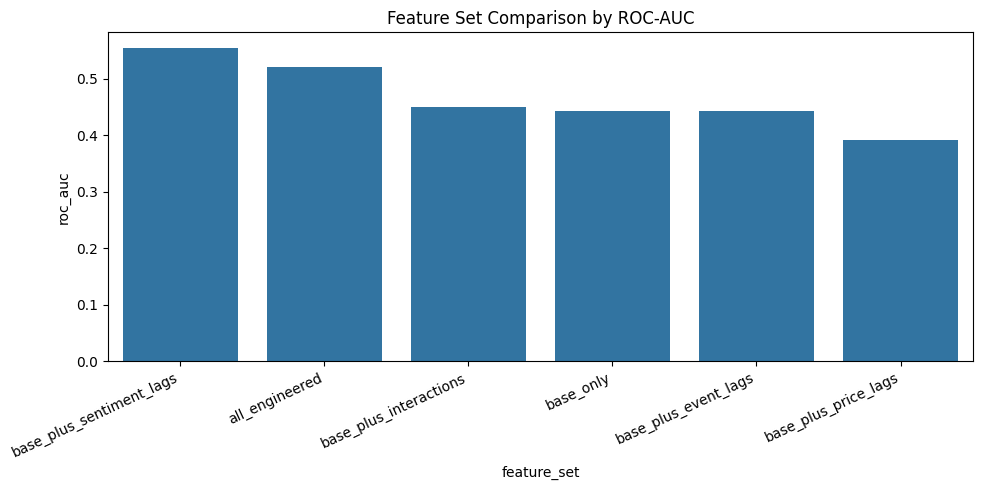

In [65]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="feature_set", y="roc_auc")
plt.xticks(rotation=25, ha="right")
plt.title("Feature Set Comparison by ROC-AUC")
plt.tight_layout()
plt.show()

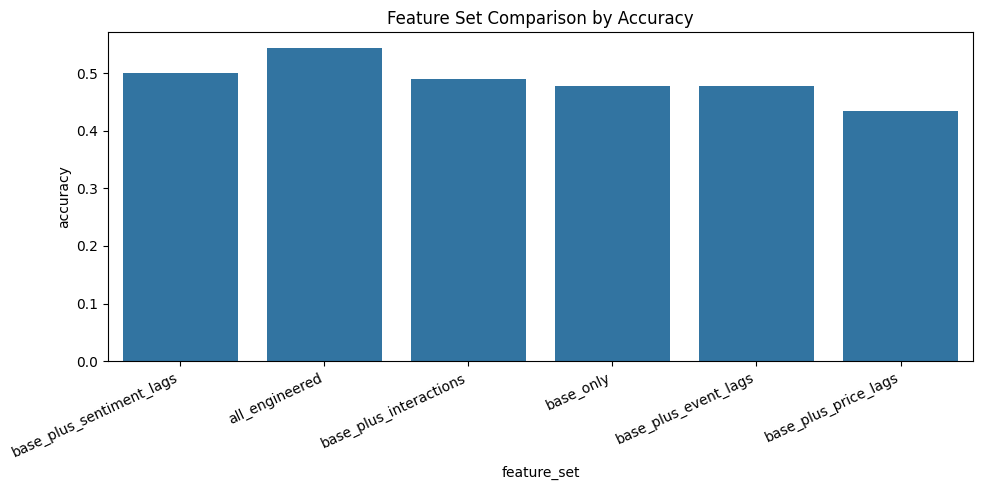

In [66]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="feature_set", y="accuracy")
plt.xticks(rotation=25, ha="right")
plt.title("Feature Set Comparison by Accuracy")
plt.tight_layout()
plt.show()

## 13. Inspect best feature set

In [67]:
best_row = results_df.iloc[0]
best_feature_set_name = best_row["feature_set"]
best_model = best_row["model_obj"]
best_features = best_row["feature_cols"]

print("Best feature set:", best_feature_set_name)
print("Best accuracy   :", best_row["accuracy"])
print("Best F1         :", best_row["f1"])
print("Best ROC-AUC    :", best_row["roc_auc"])
print("No. features    :", best_row["n_features"])

Best feature set: base_plus_sentiment_lags
Best accuracy   : 0.5
Best F1         : 0.5
Best ROC-AUC    : 0.554342667299478
No. features    : 21


## 14. Feature importance

In [68]:
importances = pd.DataFrame({
    "feature": best_features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

importances.head(20)

,feature,importance
3,log_return,0.105723
12,sentiment_std_lag1,0.071461
10,avg_sentiment_lag2,0.060289
4,roll5_ret,0.055319
19,sentiment_std_roll3_mean,0.055125
1,sentiment_std,0.054542
20,sentiment_std_roll5_mean,0.051030
6,roll20_vol,0.050493
5,roll10_ret,0.047910
18,avg_sentiment_roll5_std,0.045109


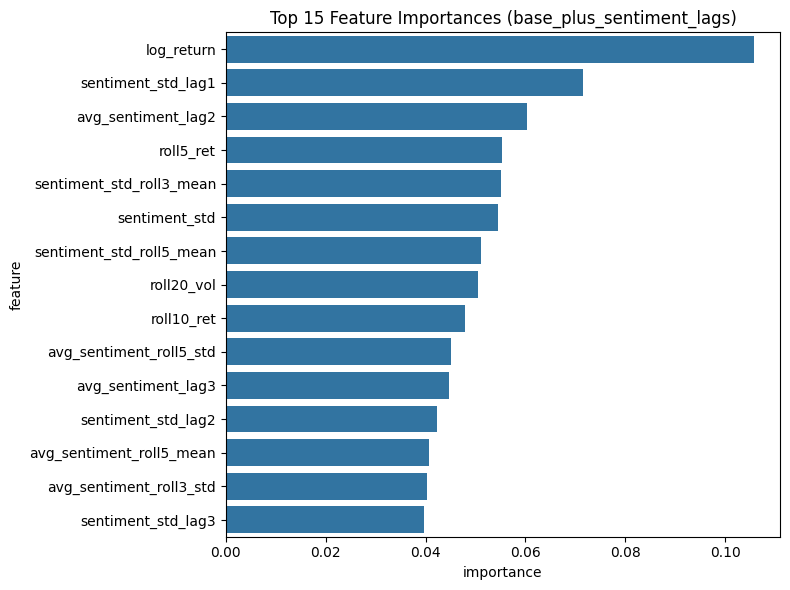

In [70]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importances.head(15), y="feature", x="importance")
plt.title(f"Top 15 Feature Importances ({best_feature_set_name})")
plt.tight_layout()
plt.show()

## 15. Save merged dataset

In [71]:
df.to_csv(MERGED_OUTPUT_PATH, index=False)
print("Saved merged dataset to:", MERGED_OUTPUT_PATH)
print("Final shape:", df.shape)

Saved merged dataset to: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\prediction\pipeline_outputs\merged_modeling_brent.csv
Final shape: (457, 41)


In [72]:
selected_top_features = importances.head(15)["feature"].tolist()

metadata = {
    "best_feature_set": best_feature_set_name,
    "best_metrics": {
        "accuracy": float(best_row["accuracy"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row["roc_auc"]),
    },
    "selected_top_features": selected_top_features
}

with open(META_OUTPUT_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata to:", META_OUTPUT_PATH)

Saved metadata to: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\prediction\pipeline_outputs\feature_engineering_metadata_brent.json


## What this means

Feature engineering experiments show that incorporating lagged sentiment features improves predictive performance compared to using only raw sentiment and price features. However, increasing feature complexity does not necessarily improve performance, as models using all engineered features performed worse due to increased noise and overfitting. This suggests that careful feature selection is more important than simply increasing feature quantity.

## Next steps (before next notebook)

### Choose only useful features.

In [100]:
top_features = importances.head(10)["feature"].tolist()
print(top_features)

['log_return', 'sentiment_std_lag1', 'avg_sentiment_lag2', 'roll5_ret', 'sentiment_std_roll3_mean', 'sentiment_std', 'sentiment_std_roll5_mean', 'roll20_vol', 'roll10_ret', 'avg_sentiment_roll5_std']


In [101]:
top_result = evaluate_feature_set(
    train_df,
    test_df,
    top_features,
    TARGET_COL
)

print(f"accuracy: {top_result['accuracy']}, f1: {top_result['f1']}, roc_auc: {top_result['roc_auc']}")

accuracy: 0.5217391304347826, f1: 0.5416666666666666, roc_auc: 0.5021357380161366


### Add stronger sentiment features

In [102]:
split_idx = int(len(df) * 0.8)
split_date = df.loc[split_idx, "date"]

print("Split date:", split_date)

Split date: 2025-10-13 00:00:00


In [103]:
train_df = df[df["date"] < split_date].copy()
test_df  = df[df["date"] >= split_date].copy()

In [104]:
feature_sets["new_sentiment_features"] = [
    "avg_sentiment",
    "sentiment_std",
    "sentiment_lag1",
    "sentiment_lag2",
    "sentiment_momentum",
    "sentiment_trend3"
]

In [105]:
new_result = evaluate_feature_set(
    train_df,
    test_df,
    feature_sets["new_sentiment_features"],
    TARGET_COL
)


print(f"accuracy: {top_result['accuracy']}, f1: {top_result['f1']}, roc_auc: {top_result['roc_auc']}")

accuracy: 0.5217391304347826, f1: 0.5416666666666666, roc_auc: 0.5021357380161366


In [89]:
simple_features = [
    "avg_sentiment",
    "sentiment_std",
    "sentiment_lag1",
    "sentiment_lag2",
    "log_return",
    "roll5_ret",
    "roll20_vol"
]

In [99]:
top_result = evaluate_feature_set(
    train_df,
    test_df,
    simple_features,
    TARGET_COL
)

print(f"accuracy: {top_result['accuracy']}, f1: {top_result['f1']}, roc_auc: {top_result['roc_auc']}")

accuracy: 0.4673913043478261, f1: 0.5333333333333333, roc_auc: 0.4352159468438538


Top features:

`['log_return', 'sentiment_std_lag1', 'avg_sentiment_lag2', 'roll5_ret', 'sentiment_std_roll3_mean', 'sentiment_std', 'sentiment_std_roll5_mean', 'roll20_vol', 'roll10_ret', 'avg_sentiment_roll5_std']`

In [107]:
selected_top_features = importances.head(10)["feature"].tolist()

metadata = {
    "best_feature_set": best_feature_set_name,
    "best_metrics": {
        "accuracy": float(best_row["accuracy"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row["roc_auc"]),
    },
    "selected_top_features": selected_top_features
}

with open(META_OUTPUT_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(metadata)

{'best_feature_set': 'base_plus_sentiment_lags', 'best_metrics': {'accuracy': 0.5, 'f1': 0.5, 'roc_auc': 0.554342667299478}, 'selected_top_features': ['log_return', 'sentiment_std_lag1', 'avg_sentiment_lag2', 'roll5_ret', 'sentiment_std_roll3_mean', 'sentiment_std', 'sentiment_std_roll5_mean', 'roll20_vol', 'roll10_ret', 'avg_sentiment_roll5_std']}
